In [1]:
# Cell 1 — Setup + hourly Binance data load
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

from backtest.data import DataPanel, FieldSpec

# --- Universe (top 20 by mcap, CoinMarketCap 2024-06-06; MATIC renamed POL 2024-09-04) ---
TICKERS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "DOGEUSDT", "ADAUSDT", "SHIBUSDT", "AVAXUSDT", "DOTUSDT",
    "LINKUSDT", "TRXUSDT", "BCHUSDT", "NEARUSDT", "MATICUSDT",
    "UNIUSDT", "LTCUSDT", "ICPUSDT", "ETCUSDT", "HBARUSDT",
]
MATIC_TO_POL_DATE = pd.Timestamp("2024-09-04", tz="UTC")
START_UTC = pd.Timestamp("2019-01-01", tz="UTC")
END_UTC   = pd.Timestamp.now(tz="UTC").floor("h")

CACHE_DIR = Path("data")
CACHE_DIR.mkdir(exist_ok=True)
CACHE = CACHE_DIR / "binance_hourly.parquet"

BINANCE_URL = "https://api.binance.com/api/v3/klines"
KLINES_COLS = [
    "open_time", "open", "high", "low", "close", "base_volume", "close_time",
    "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignored",
]

def fetch_klines(symbol, start_ms, end_ms, interval="1h", session=None):
    """Pull all 1h klines for [start_ms, end_ms]. Returns DataFrame indexed by open_time (UTC)."""
    sess = session or requests.Session()
    out = []
    cur = start_ms
    while cur <= end_ms:
        params = dict(symbol=symbol, interval=interval, startTime=cur, endTime=end_ms, limit=1000)
        for attempt in range(5):
            r = sess.get(BINANCE_URL, params=params, timeout=30)
            if r.status_code == 200:
                break
            if r.status_code in (429, 418):
                time.sleep(2 ** attempt)
                continue
            if r.status_code == 400:
                # Symbol not yet listed / invalid for this window
                return pd.DataFrame(columns=KLINES_COLS).set_index("open_time")
            r.raise_for_status()
        else:
            raise RuntimeError(f"{symbol}: too many retries at {cur}")
        rows = r.json()
        if not rows:
            break
        out.extend(rows)
        last_open = rows[-1][0]
        if len(rows) < 1000:
            break
        cur = last_open + 60 * 60 * 1000  # next hour
        time.sleep(0.12)  # ~8 req/s, well below limit
    if not out:
        return pd.DataFrame(columns=KLINES_COLS).set_index("open_time")
    df = pd.DataFrame(out, columns=KLINES_COLS)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "base_volume", "quote_volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.set_index("open_time").sort_index()
    return df[~df.index.duplicated()]

if CACHE.exists():
    print(f"Loading cached panel from {CACHE} ...")
    raw = pd.read_parquet(CACHE)
else:
    symbols = TICKERS + ["POLUSDT"]
    print(f"Pulling hourly klines for {len(symbols)} symbols from Binance ...")
    session = requests.Session()
    frames = {}
    for i, sym in enumerate(symbols, 1):
        t0 = time.time()
        df = fetch_klines(
            sym,
            int(START_UTC.timestamp() * 1000),
            int(END_UTC.timestamp() * 1000),
            session=session,
        )
        print(f"  [{i:2d}/{len(symbols)}] {sym:10s} bars={len(df):7d}  in {time.time()-t0:5.1f}s")
        frames[sym] = df[["close", "quote_volume"]]
    pieces = []
    for sym, df in frames.items():
        if df.empty:
            continue
        pieces.append(df.reset_index().assign(symbol=sym))
    raw = pd.concat(pieces, ignore_index=True)
    raw.to_parquet(CACHE)
    print(f"Cached → {CACHE}")

# --- Stitch MATICUSDT (pre-2024-09-04) + POLUSDT (on/after) into a single 'MATICUSDT' column ---
matic = raw[raw["symbol"] == "MATICUSDT"]
pol   = raw[raw["symbol"] == "POLUSDT"]
matic_keep = matic[matic["open_time"] <  MATIC_TO_POL_DATE]
pol_keep   = pol  [pol  ["open_time"] >= MATIC_TO_POL_DATE]
stitched = pd.concat([matic_keep, pol_keep], ignore_index=True).assign(symbol="MATICUSDT")
raw_x = pd.concat([raw[~raw["symbol"].isin(["MATICUSDT", "POLUSDT"])], stitched], ignore_index=True)

# --- Pivot to (date × asset); reindex to a continuous hourly grid (NaN where not yet listed) ---
close = (raw_x.pivot(index="open_time", columns="symbol", values="close")
              .reindex(columns=TICKERS).sort_index())
qvol  = (raw_x.pivot(index="open_time", columns="symbol", values="quote_volume")
              .reindex(columns=TICKERS).sort_index())
full_idx = pd.date_range(close.index.min(), close.index.max(), freq="1h", tz="UTC")
close = close.reindex(full_idx)
qvol  = qvol.reindex(full_idx)
# DataPanel expects a DatetimeIndex; tz-naive UTC is the convention.
close.index = close.index.tz_convert("UTC").tz_localize(None)
qvol.index  = qvol.index.tz_convert("UTC").tz_localize(None)

# --- Build DataPanel ---
panel = DataPanel(
    prices=close,
    volume=qvol,
    specs={"prices": FieldSpec(lag=0), "volume": FieldSpec(lag=0)},
    check_outliers=True,
)

print(f"\nBars       : {len(panel.dates):,}")
print(f"Assets     : {len(panel.assets_all)}")
print(f"Range      : {panel.dates[0]} → {panel.dates[-1]}")
print(f"NaN prices : {close.isna().mean().mean():.2%} (expected: late-listing coins like SHIB/ICP start ~May-2021)")
print(f"NaN volume : {qvol.isna().mean().mean():.2%}")
print("\nclose.tail(3):")
print(close.tail(3))


Loading cached panel from data\binance_hourly.parquet ...



Bars       : 64,693
Assets     : 20
Range      : 2019-01-01 00:00:00 → 2026-05-19 12:00:00
NaN prices : 10.71% (expected: late-listing coins like SHIB/ICP start ~May-2021)
NaN volume : 10.71%

close.tail(3):
symbol                BTCUSDT  ETHUSDT  BNBUSDT  SOLUSDT  XRPUSDT  DOGEUSDT  \
2026-05-19 10:00:00  77041.87  2118.36   640.07    84.70   1.3744   0.10421   
2026-05-19 11:00:00  76714.62  2110.85   639.88    84.39   1.3722   0.10372   
2026-05-19 12:00:00  76831.18  2116.67   640.74    84.63   1.3749   0.10412   

symbol               ADAUSDT  SHIBUSDT  AVAXUSDT  DOTUSDT  LINKUSDT  TRXUSDT  \
2026-05-19 10:00:00   0.2499  0.000006      9.16    1.235      9.61   0.3551   
2026-05-19 11:00:00   0.2486  0.000006      9.10    1.229      9.54   0.3552   
2026-05-19 12:00:00   0.2496  0.000006      9.15    1.234      9.57   0.3557   

symbol               BCHUSDT  NEARUSDT  MATICUSDT  UNIUSDT  LTCUSDT  ICPUSDT  \
2026-05-19 10:00:00    373.6     1.609     0.0909    3.493    54.27    2.

C:\Users\User\backtest_engine\backtest\data\panel.py:172: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = self._prices.pct_change()
C:\Users\User\AppData\Local\Temp\ipykernel_28528\2666391710.py:118: UserWarning: DataPanel: 10869 bar(s) with |return - median| > 10.0*MAD detected.
  Top examples:
    2021-01-29 DOGEUSDT: ret=+70.02%, mad_score=170.1
    2020-02-11 HBARUSDT: ret=+68.13%, mad_score=132.4
    2021-01-29 TRXUSDT: ret=+31.10%, mad_score=119.5
    2021-01-28 DOGEUSDT: ret=+48.58%, mad_score=118.0
    2019-06-13 LINKUSDT: ret=+54.34%, mad_score=106.1
  Verify these are real moves, not bad ticks. Pass check_outliers=False to silence.
  panel = DataPanel(


In [2]:
# Cell 2 — Hurst pairs Strategy class
import sys, subprocess
try:
    from statsmodels.tsa.stattools import coint
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.stattools import coint

from itertools import combinations
import numpy as np
import pandas as pd

from backtest.strategy import Strategy


class HurstPairsStrategy(Strategy):
    """Hurst-Crypto-Pairs trading (mathematics-12-02911).

    Entry: H_t<0.5 and spread in [m±1σ, m±2σ] band (windows ending t-1).
    Exit:  mean reversion / 2σ stop / 72h expiration.
    Pair selection: monthly top-K by lowest ADF p-value on OLS residual of log-price regression.

    Implementation notes:
      • b_t (hedge ratio) is recomputed at every bar from the rolling 30-day vol ratio
        of log returns ending at t-1 (paper-faithful).
      • Spreads in the rolling tw_hours window each use their own contemporaneous b.
      • All windows for m, std, H end at t-1 (no look-ahead).
      • State (selected pairs, open trades) lives on self → deep-copied per CPCV fold.
    """

    rebalance_frequency = "D"  # "D"/"daily"/"B" = every bar (here: every hour)

    def __init__(
        self,
        tw_hours: int = 168,
        hedge_lookback_hours: int = 720,
        hurst_q: int = 1,
        hurst_threshold: float = 0.5,
        entry_lower_std: float = 1.0,
        entry_upper_std: float = 2.0,
        stop_std: float = 2.0,
        max_hold_hours: int = 72,
        top_k_pairs: int = 20,
        coint_lookback_hours: int = 4320,   # 180 days
        pair_gross_alloc: float = 0.05,
    ):
        self.tw_hours = tw_hours
        self.hedge_lookback_hours = hedge_lookback_hours
        self.hurst_q = hurst_q
        self.hurst_threshold = hurst_threshold
        self.entry_lower_std = entry_lower_std
        self.entry_upper_std = entry_upper_std
        self.stop_std = stop_std
        self.max_hold_hours = max_hold_hours
        self.top_k_pairs = top_k_pairs
        self.coint_lookback_hours = coint_lookback_hours
        self.pair_gross_alloc = pair_gross_alloc

        # tau = 2^n for n = 0..floor(log2(TW))-2  (Eq. 4; TW=168 -> tau in {1,2,4,8,16,32})
        n_max = max(0, int(np.floor(np.log2(tw_hours))) - 2)
        self._taus = np.array([2 ** n for n in range(n_max + 1)], dtype=int)

        # State (deep-copied per CPCV path, so no leakage across folds)
        self._current_month = None
        self._selected_pairs = []         # list of (A, B) tuples for the current month
        self.open_trades = {}             # (A, B) -> {"entry_t", "side", "m0", "std0"}
        self._event_this_bar = False      # True iff open_trades mutated during the most recent
                                          # generate_weights call; used by apply_risk to suppress
                                          # mark-to-market micro-rebalancing trades on quiet bars.

    def __repr__(self):
        return (
            f"HurstPairsStrategy(tw={self.tw_hours},hl={self.hedge_lookback_hours},"
            f"q={self.hurst_q},Hth={self.hurst_threshold},"
            f"band=({self.entry_lower_std},{self.entry_upper_std}),"
            f"stop={self.stop_std},hold={self.max_hold_hours},"
            f"k={self.top_k_pairs},clb={self.coint_lookback_hours},"
            f"alloc={self.pair_gross_alloc})"
        )

    def required_data(self):
        return {"prices": None}

    # ---------- Hurst exponent (q-order, local) ----------
    def _local_hurst(self, x):
        """H from regressing log K_q(tau) on log tau, with K_q(tau) prop to tau^(qH)."""
        x = np.asarray(x, dtype=float)
        if np.isnan(x).any():
            return np.nan
        q = self.hurst_q
        denom = np.mean(np.abs(x) ** q)
        if denom <= 0 or not np.isfinite(denom):
            return np.nan
        log_tau, log_k = [], []
        for tau in self._taus:
            if tau >= len(x):
                return np.nan
            incr = np.abs(x[tau:] - x[:-tau]) ** q
            k = incr.mean() / denom
            if k <= 0 or not np.isfinite(k):
                return np.nan
            log_tau.append(np.log(tau))
            log_k.append(np.log(k))
        slope, _ = np.polyfit(np.array(log_tau), np.array(log_k), 1)
        return slope / q

    # ---------- Per-bar signal computation (no lookahead, rolling b) ----------
    def _signal_at_t(self, prices_hist, a, b_sym):
        """Compute (s_t, m, std, H, b_t) at the current bar t (= last bar in prices_hist).

        b_t   uses returns of (a, b_sym) ending at t-1 over hedge_lookback_hours.
        Each historical spread s_τ in the m/std/H window uses its own contemporaneous b_τ.
        m, std, H are computed over s_{t-tw}..s_{t-1}.
        Returns dict or None if data insufficient / non-finite.
        """
        # Current bar must have both legs priced; else we can't form s_t (engine will
        # zero the asset weight too via its eligibility filter).
        if pd.isna(prices_hist[a].iloc[-1]) or pd.isna(prices_hist[b_sym].iloc[-1]):
            return None

        # Use the most recent contiguous non-NaN bars. Binance has ~0.1% maintenance
        # gaps; dropna and treat surviving rows as adjacent (vol/rolling stats are
        # then computed on non-NaN consecutive samples).
        n_needed = self.hedge_lookback_hours + self.tw_hours + 2
        sub_all = prices_hist[[a, b_sym]].dropna()
        if len(sub_all) < n_needed:
            return None
        sub = sub_all.iloc[-(n_needed + 200):]
        n = len(sub)

        log_a = np.log(sub[a].values)
        log_b = np.log(sub[b_sym].values)
        lr_a = np.diff(log_a)    # length n-1; lr_a[k] is the return at sub bar k+1
        lr_b = np.diff(log_b)

        # Rolling vol: pandas rolling(window).std() at index i uses lr[i-window+1..i]
        vol_a = pd.Series(lr_a).rolling(self.hedge_lookback_hours).std().values
        vol_b = pd.Series(lr_b).rolling(self.hedge_lookback_hours).std().values

        # b at sub bar j (j>=2) uses vol over returns ending at sub bar j-1
        # → window ends at lr-index j-2 → vol_a[j-2] / vol_b[j-2].
        b_at_sub = np.full(n, np.nan)
        if n >= 3:
            with np.errstate(divide="ignore", invalid="ignore"):
                ratio = np.where(vol_b[:-1] > 0, vol_a[:-1] / vol_b[:-1], np.nan)
            b_at_sub[2:] = ratio  # b_at_sub[j] = vol_a[j-2]/vol_b[j-2] for j in 2..n-1

        s = log_a - b_at_sub * log_b   # spread at each sub bar (NaN where b not yet defined)

        s_t = s[-1]
        s_window = s[-(self.tw_hours + 1):-1]   # length tw_hours, ending at t-1

        if (
            len(s_window) < self.tw_hours
            or np.isnan(s_window).any()
            or not np.isfinite(s_t)
        ):
            return None

        m_val = float(s_window.mean())
        std_val = float((s_window - m_val).std(ddof=1))
        h_val = self._local_hurst(s_window)

        if not (np.isfinite(std_val) and np.isfinite(h_val)) or std_val == 0.0:
            return None

        return {"s": float(s_t), "m": m_val, "std": std_val, "h": float(h_val), "b": float(b_at_sub[-1])}

    # ---------- Monthly cointegration ranking ----------
    def _select_pairs(self, prices_hist):
        """Top-K pairs by lowest ADF p-value on OLS residual, over the last coint_lookback_hours."""
        recent = prices_hist.iloc[-self.coint_lookback_hours:]
        cols = [c for c in recent.columns
                if recent[c].notna().sum() >= self.coint_lookback_hours * 0.9]
        scores = []
        for a, b in combinations(cols, 2):
            sub = recent[[a, b]].dropna()
            if len(sub) < self.coint_lookback_hours * 0.9:
                continue
            la = np.log(sub[a].values)
            lb = np.log(sub[b].values)
            try:
                _, p, _ = coint(la, lb, trend="c", autolag=None, maxlag=1)
            except Exception:
                continue
            if np.isfinite(p):
                scores.append(((a, b), p))
        scores.sort(key=lambda kv: kv[1])
        return [pair for pair, _ in scores[: self.top_k_pairs]]

    # ---------- Engine entry point ----------
    def generate_weights(self, data, t):
        self._event_this_bar = False     # reset; will flip to True iff open_trades mutates
        prices = data.prices
        # Index by panel-wide assets (data.prices.columns), NOT data.assets — the latter
        # excludes assets with NaN at t, but an open trade may involve a leg that's
        # temporarily NaN (Binance maintenance gap). Engine reindexes our output anyway
        # and zeros out ineligible names via its own filter (skills/02-strategy.md §3).
        weights = pd.Series(0.0, index=prices.columns)

        ts = pd.Timestamp(t)
        ym = (ts.year, ts.month)

        # Month change → re-rank pairs (using data through t, inclusive)
        if ym != self._current_month:
            self._current_month = ym
            if len(prices) >= self.coint_lookback_hours:
                self._selected_pairs = self._select_pairs(prices)

        if not self._selected_pairs and not self.open_trades:
            return weights

        k_leg = self.pair_gross_alloc / 2.0   # equal-dollar legs

        # ---- Exit pass: re-evaluate every currently open trade ----
        for pair in list(self.open_trades.keys()):
            a, b = pair
            sig = self._signal_at_t(prices, a, b)
            if sig is None:
                # Can't price the pair right now → hold position; will retry next bar
                trade = self.open_trades[pair]
                side = trade["side"]
                if side == -1:
                    weights[a] += +k_leg; weights[b] += -k_leg
                else:
                    weights[a] += -k_leg; weights[b] += +k_leg
                continue

            s_t = sig["s"]
            trade = self.open_trades[pair]
            m0, std0, side = trade["m0"], trade["std0"], trade["side"]
            hours_held = int((t - trade["entry_t"]) / pd.Timedelta("1h"))

            exit_now = False
            if side == +1 and s_t <= m0:                              # sold pair: spread reverted down
                exit_now = True
            elif side == -1 and s_t >= m0:                            # bought pair: spread reverted up
                exit_now = True
            elif side == +1 and s_t >= m0 + self.stop_std * std0:     # 2σ stop
                exit_now = True
            elif side == -1 and s_t <= m0 - self.stop_std * std0:
                exit_now = True
            elif hours_held >= self.max_hold_hours:                   # 72h expiration
                exit_now = True

            if exit_now:
                del self.open_trades[pair]
                self._event_this_bar = True
            else:
                if side == -1:
                    weights[a] += +k_leg; weights[b] += -k_leg
                else:
                    weights[a] += -k_leg; weights[b] += +k_leg

        # ---- Entry pass: scan selected (top-K) pairs not already open ----
        for pair in self._selected_pairs:
            if pair in self.open_trades:
                continue
            a, b = pair
            sig = self._signal_at_t(prices, a, b)
            if sig is None:
                continue
            if sig["h"] >= self.hurst_threshold:
                continue
            s_t, m_t, std_t = sig["s"], sig["m"], sig["std"]

            side = 0
            if (m_t + self.entry_lower_std * std_t) < s_t < (m_t + self.entry_upper_std * std_t):
                side = +1   # sell pair (short A, long B)
            elif (m_t - self.entry_upper_std * std_t) < s_t < (m_t - self.entry_lower_std * std_t):
                side = -1   # buy  pair (long A, short B)

            if side != 0:
                self.open_trades[pair] = {
                    "entry_t": t, "side": side, "m0": m_t, "std0": std_t,
                }
                self._event_this_bar = True
                if side == -1:
                    weights[a] += +k_leg; weights[b] += -k_leg
                else:
                    weights[a] += -k_leg; weights[b] += +k_leg

        return weights

    # ---------- Risk overlay: suppress micro-rebalance on quiet bars ----------
    def apply_risk(self, proposed, state, data):
        """If no entry/exit fired this bar, return current-weights so the engine's
        `target_$ - positions` step yields zero trades (kills mark-to-market drift trades).
        On event bars, return proposed weights normally. Always pass through the default
        RiskManager so per-asset caps / gross caps stay enforced.
        """
        equity = state["equity"]
        if not self._event_this_bar and equity > 0:
            proposed = state["positions"] / equity
        return super().apply_risk(proposed, state, data)


strat = HurstPairsStrategy()
print(strat)

rb = strat.rebalance_dates(panel.dates)
print(f"\nRebalance bars : {len(rb):,}  (every-hour -> should equal {len(panel.dates):,})")
print(f"First rebalance: {rb[0]}")
print(f"Last rebalance : {rb[-1]}")
print(f"tau for Hurst  : {strat._taus.tolist()}")
print(f"required_data(): {strat.required_data()}")

# Hurst sanity: stationary noise -> H ~ 0; random walk -> H ~ 0.5; trending -> H > 0.5
rng = np.random.default_rng(0)
noise = rng.standard_normal(168)
rw = np.cumsum(noise)
trend = np.cumsum(np.abs(noise))
print("\nHurst sanity (TW=168):")
print(f"  white noise (stationary, anti-persistent): H = {strat._local_hurst(noise):.3f}  (expect ~ 0)")
print(f"  random walk                              : H = {strat._local_hurst(rw):.3f}  (expect ~ 0.5)")
print(f"  trending series                          : H = {strat._local_hurst(trend):.3f}  (expect > 0.5)")

# _signal_at_t smoke test on a real pair from the panel
test_t = panel.dates[6000]   # ~10 months in, enough history for both windows
test_view = panel.as_of(test_t)
sig_btc_eth = strat._signal_at_t(test_view.prices, "BTCUSDT", "ETHUSDT")
print(f"\n_signal_at_t smoke test (BTC,ETH) at {test_t}:")
print(f"  {sig_btc_eth}")


HurstPairsStrategy(tw=168,hl=720,q=1,Hth=0.5,band=(1.0,2.0),stop=2.0,hold=72,k=20,clb=4320,alloc=0.05)

Rebalance bars : 64,693  (every-hour -> should equal 64,693)
First rebalance: 2019-01-01 00:00:00
Last rebalance : 2026-05-19 12:00:00
tau for Hurst  : [1, 2, 4, 8, 16, 32]
required_data(): {'prices': None}

Hurst sanity (TW=168):
  white noise (stationary, anti-persistent): H = 0.018  (expect ~ 0)
  random walk                              : H = 0.502  (expect ~ 0.5)
  trending series                          : H = 1.007  (expect > 0.5)

_signal_at_t smoke test (BTC,ETH) at 2019-09-08 00:00:00:
  {'s': 4.706183294590632, 'm': 4.426465534825788, 'std': 0.1550708955552438, 'h': 0.755846093052001, 'b': 0.8777814802065369}


In [3]:
# Cell 3 — Costs + liquidity (mandatory per PROTOCOL §6)
from backtest.costs import (
    Commission, Spread, MarketImpact, ShortBorrow,
    CompositeCostModel, LiquidityCap,
)

# Hourly crypto on Binance spot. trading_days=8760 (= 365*24) is the hourly annualization
# factor for ShortBorrow — the default 252 would silently inflate borrow ~35x.
HOURS_PER_YEAR = 365 * 24  # = 8760
BORROW_ANNUAL_BPS = 1500

costs = CompositeCostModel([
    Commission(bps=10),                                                # Binance spot taker fee
    Spread(half_bps=5),                                                # ~10 bps round-trip (mix of majors & alts)
    MarketImpact(k=10, kind="sqrt", adv_lookback=168),                 # sqrt impact, 1-week ADV
    ShortBorrow(annual_bps=BORROW_ANNUAL_BPS, trading_days=HOURS_PER_YEAR),  # 15% annual on shorts, hourly
])

liq = LiquidityCap(cap_pct=0.10, adv_lookback=168)                     # 10% of 1-week median hourly volume

# Pre-flight: volume MUST be on the panel (MarketImpact + LiquidityCap both require it).
print("Cost components :", [type(m).__name__ for m in costs.models])
for m in costs.models:
    if isinstance(m, Commission):
        print(f"  Commission        bps         = {m.bps}")
    elif isinstance(m, Spread):
        print(f"  Spread            half_bps    = {m.half_bps}")
    elif isinstance(m, MarketImpact):
        print(f"  MarketImpact      k={m.k}, kind={m.kind!r}, adv_lookback={m.adv_lookback}")
    elif isinstance(m, ShortBorrow):
        # ShortBorrow only stores daily_rate; back-derive the annualized rate from it.
        implied_annual_pct = m.daily_rate * HOURS_PER_YEAR * 100
        print(f"  ShortBorrow       per-bar rate={m.daily_rate:.3e}  (annualized = {implied_annual_pct:.2f}%)")

print(f"\nLiquidityCap      cap_pct={liq.cap_pct}, adv_lookback={liq.adv_lookback}")
print(f"Panel has volume  : {panel.has_field('volume')}  (must be True)")

# Smoke check: hand-compute one bar's cost on a trivial trade to make sure nothing blows up.
import pandas as pd
sample_view = panel.as_of(panel.dates[-1])
sample_trades = pd.Series({"BTCUSDT": 10_000.0, "ETHUSDT": -10_000.0}).reindex(panel.assets_all).fillna(0.0)
sample_positions = sample_trades.copy()
tc = costs.trade_cost(sample_trades, sample_view)
hc = costs.holding_cost(sample_positions, sample_view)
print(f"\nSmoke test (last bar, +$10k BTC / -$10k ETH):")
print(f"  trade_cost   = ${tc:,.2f}   ({tc / 20_000 * 1e4:.1f} bps of $20k notional)")
print(f"  holding_cost = ${hc:,.4f}   (only the $10k short ETH leg charged; annualized = {hc / 10_000 * HOURS_PER_YEAR * 100:.2f}%)")


Cost components : ['Commission', 'Spread', 'MarketImpact', 'ShortBorrow']
  Commission        bps         = 10
  Spread            half_bps    = 5
  MarketImpact      k=10, kind='sqrt', adv_lookback=168
  ShortBorrow       per-bar rate=1.712e-05  (annualized = 15.00%)

LiquidityCap      cap_pct=0.1, adv_lookback=168
Panel has volume  : True  (must be True)

Smoke test (last bar, +$10k BTC / -$10k ETH):
  trade_cost   = $30.01   (15.0 bps of $20k notional)
  holding_cost = $0.1712   (only the $10k short ETH leg charged; annualized = 15.00%)


In [4]:
# Cell 4 — Single-path Engine run
import time
from backtest.engine import Engine

WARMUP_BARS = 5400   # coint_lookback (4320) + hedge (720) + tw (168) + ~8d buffer

engine = Engine(
    panel,
    strat,
    costs=costs,
    liquidity=liq,
    initial_capital=1_000_000.0,
)

print(f"Engine constructed. Starting backtest from {panel.dates[WARMUP_BARS]} ...")
print(f"Expected runtime: 25-35 min (60k hourly bars × 20 pairs × per-bar rolling signal)\n")

t0 = time.time()
result = engine.run(start=panel.dates[WARMUP_BARS])
elapsed = time.time() - t0
print(f"...done in {elapsed/60:.1f} min.\n")

# Validation block (skills/05-engine-single-path.md §9)
md = result.metadata
init_cap = md["initial_capital"]
final_eq = result.equity_curve.iloc[-1]
total_ret = final_eq / init_cap - 1

print(f"Bars                 : {len(result.equity_curve):,}")
print(f"Rebalances           : {md['n_rebalances']:,}  (expected = bars, hourly)")
print(f"Date range           : {md['start']} -> {md['end']}")
print(f"Initial capital      : ${init_cap:>14,.0f}")
print(f"Final equity         : ${final_eq:>14,.0f}")
print(f"Total return         : {total_ret:+.2%}")
print(f"Total costs paid     : ${result.costs.sum():>14,.0f}")
print(f"Max |position weight|: {result.weights.abs().max().max():.2%}    (cap = 20% by DEFAULT_RISK_CONFIG)")
print(f"Max gross exposure   : {result.weights.abs().sum(axis=1).max():.2%}    (cap = 100% by DEFAULT_RISK_CONFIG)")
print(f"Max net exposure     : {result.weights.sum(axis=1).abs().max():.2%}    (cap = 100%, paper-style $-neutral expects ~0%)")
print(f"Open trades at end   : {len(strat.open_trades)}")
print(f"Unfilled (sum |$|)   : ${result.unfilled.abs().sum().sum():>14,.0f}    (= LiquidityCap throttling)")

# Tiny sanity: how many bars had any non-zero exposure?
non_idle = (result.weights.abs().sum(axis=1) > 1e-6).sum()
print(f"Bars with exposure   : {non_idle:,} / {len(result.equity_curve):,}  ({non_idle/len(result.equity_curve):.1%})")


Engine constructed. Starting backtest from 2019-08-14 00:00:00 ...
Expected runtime: 25-35 min (60k hourly bars × 20 pairs × per-bar rolling signal)



...done in 34.7 min.

Bars                 : 59,293
Rebalances           : 59,293  (expected = bars, hourly)
Date range           : 2019-08-14 00:00:00 -> 2026-05-19 12:00:00
Initial capital      : $     1,000,000
Final equity         : $       104,046
Total return         : -89.60%
Total costs paid     : $       825,914
Max |position weight|: 17.50%    (cap = 20% by DEFAULT_RISK_CONFIG)
Max gross exposure   : 60.01%    (cap = 100% by DEFAULT_RISK_CONFIG)
Max net exposure     : 15.03%    (cap = 100%, paper-style $-neutral expects ~0%)
Open trades at end   : 6
Unfilled (sum |$|)   : $   196,123,240    (= LiquidityCap throttling)
Bars with exposure   : 57,260 / 59,293  (96.6%)


PART A — COST BREAKDOWN ($836k total)



Component                   Total ($)  % of costs   % of capital
----------------------------------------------------------------------
Commission (10 bps)    $      507,051       61.4%          50.7%
Spread (5 bps half)    $      253,526       30.7%          25.4%
MarketImpact (k=10)    $       34,741        4.2%           3.5%
ShortBorrow (15%)      $       28,565        3.5%           2.9%
----------------------------------------------------------------------
TOTAL (re-computed)    $      823,883
TOTAL (result.costs)   $      825,914  ← engine canonical
Reconciliation diff   :   0.25%

PART B — TRADE STATISTICS

Bars with non-zero trades  : 29,465 / 59,293  (49.7%)
Total notional traded      : $   507,051,457
Avg notional / trade-bar   : $        17,209
Avg gross exposure         : 14.09%
Avg net exposure (signed)  : -0.07%
Avg |net exposure|         : 1.07%
Unfilled / total notional  : 38.7%  ← LiquidityCap throttling rate

PART C — EQUITY / DD / COSTS plot


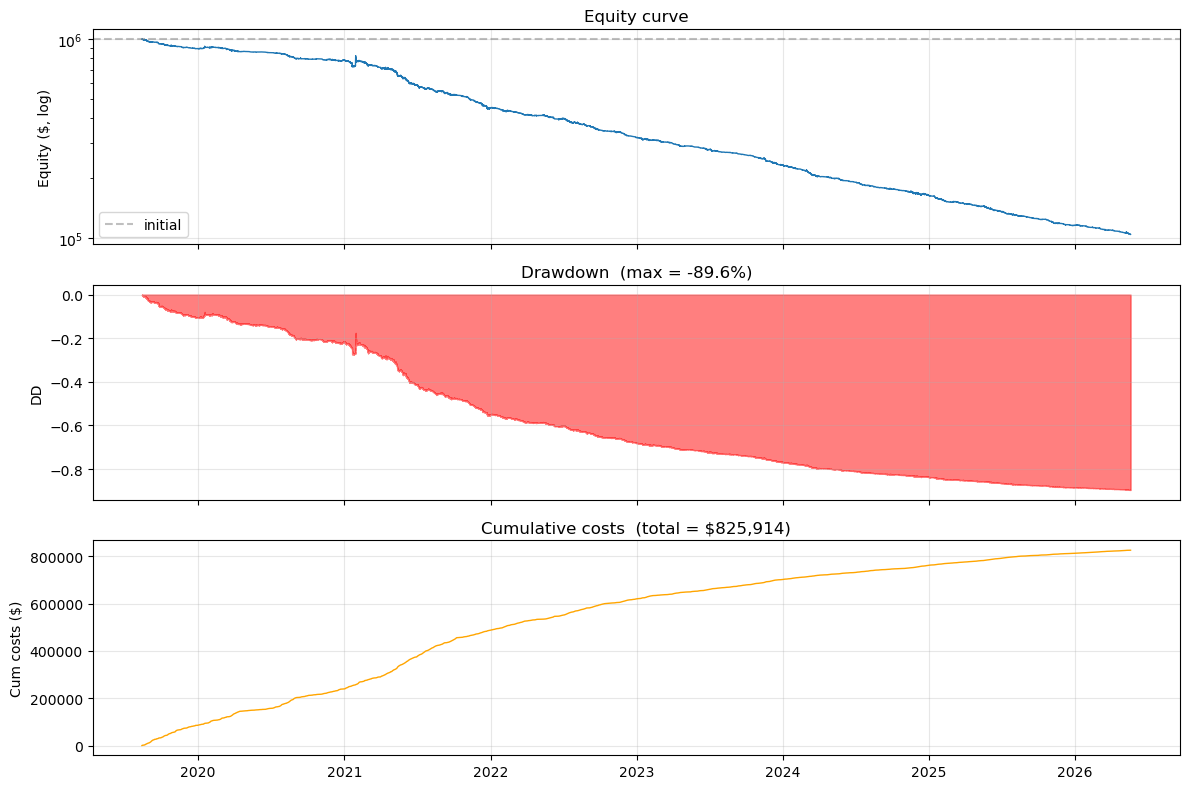


PART D — DOES H<0.5 ACTUALLY CORRELATE WITH FASTER MEAN REVERSION?

Paper's claim: 'pairs with anti-persistent H revert significantly faster'
Test: among ALL bars where spread is in the [1σ, 2σ] entry band (regardless of H),
      stratify time-to-mean-reversion (HMR, capped at 72h) by Hurst bucket.

Ranking pairs by coint p-value over panel.dates[20000:24320]...


Top-10 pairs:
   1. DOGEUSDT  / LTCUSDT     coint p = 0.0000
   2. DOGEUSDT  / BCHUSDT     coint p = 0.0000
   3. DOGEUSDT  / LINKUSDT    coint p = 0.0000
   4. DOGEUSDT  / UNIUSDT     coint p = 0.0000
   5. DOGEUSDT  / TRXUSDT     coint p = 0.0000
   6. DOGEUSDT  / DOTUSDT     coint p = 0.0000
   7. BCHUSDT   / LTCUSDT     coint p = 0.0000
   8. XRPUSDT   / DOGEUSDT    coint p = 0.0001
   9. BNBUSDT   / DOGEUSDT    coint p = 0.0008
  10. DOGEUSDT  / NEARUSDT    coint p = 0.0010
  Scanning DOGEUSDT/LTCUSDT...

  signals=26,861
  Scanning DOGEUSDT/BCHUSDT...

  signals=25,512
  Scanning DOGEUSDT/LINKUSDT...

  signals=27,062
  Scanning DOGEUSDT/UNIUSDT...

...

  signals=20,885
  Scanning BCHUSDT/LTCUSDT...

  signals=24,871
  Scanning XRPUSDT/DOGEUSDT...

  signals=26,485
  Scanning BNBUSDT/DOGEUSDT...

  signals=26,028
  Scanning DOGEUSDT/NEARUSDT...

  signals=18,964

Total signals: 244,379  (scan took 50.9s)

Bucket                                         N   Mean HMR  Median HMR   % revert<72h
------------------------------------------------------------------------------------------
Strongly anti-persistent (H<0.3)           1,113       39.4        32.0          63.8%
Mild anti-persistent   (0.3≤H<0.5)        45,452       52.9        73.0          44.8%
Near-random            (0.5≤H<0.7)       120,374       64.0        73.0          23.5%
Strongly persistent    (H≥0.7)            77,440       70.2        73.0           8.2%


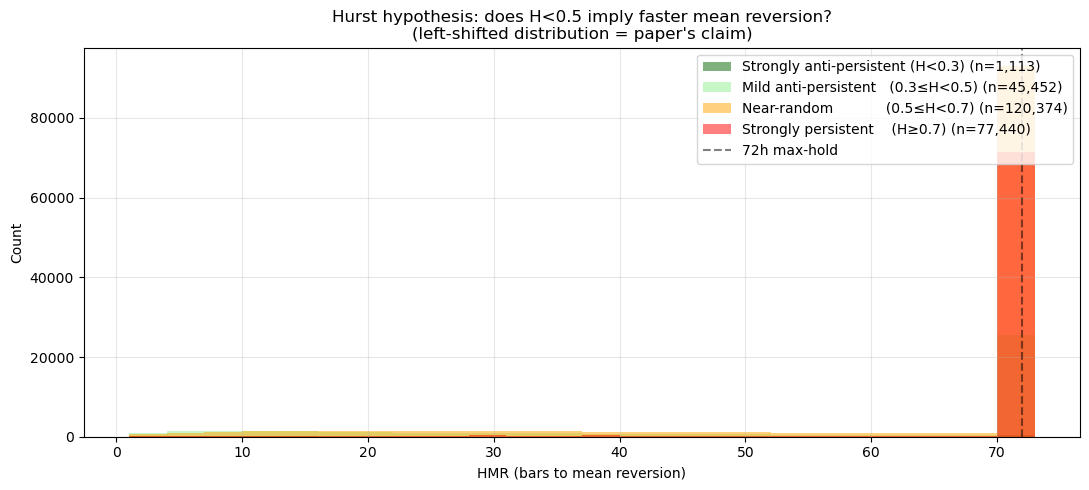


Mann-Whitney U test (one-sided)
  H0: HMR(H<0.5) is NOT stochastically less than HMR(H≥0.5)
  H1: HMR(H<0.5) IS less (paper's claim)
  N(anti)=46,565, N(pers)=197,814
  Mean HMR: anti=52.59h, pers=66.40h  (diff = -13.81h)
  U = 3247035906, p-value = 0.000000
  → REJECT H0 at α=0.01:  H<0.5 DOES revert faster (paper's claim supported)


In [5]:
# Cell 5 — Stage 4 diagnostics: cost breakdown + Hurst hypothesis test
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu

# Re-use names from earlier cells: panel, result, close, qvol, strat, costs, liq, HOURS_PER_YEAR, BORROW_ANNUAL_BPS
# All cost params are kept consistent with Cell 3.

# ============================================================
# PART A — Cost breakdown (re-evaluate each component vectorized)
# ============================================================
print("=" * 70)
print("PART A — COST BREAKDOWN ($836k total)")
print("=" * 70)

trades = result.trades.reindex(columns=close.columns).fillna(0.0)
positions = result.positions.reindex(columns=close.columns).fillna(0.0)
# Align prices/volume to result.equity_curve.index (post-warmup window)
prices_run = close.reindex(result.equity_curve.index)
volume_run = qvol.reindex(result.equity_curve.index)

# Commission(bps=10): cost = |trades|.sum() * bps/1e4
commission_per_bar = trades.abs().sum(axis=1) * 10 / 1e4
# Spread(half_bps=5): cost = |trades|.sum() * half_bps/1e4
spread_per_bar = trades.abs().sum(axis=1) * 5 / 1e4
# ShortBorrow: cost = |shorts|.sum() * daily_rate, where daily_rate = 1500/1e4/HOURS_PER_YEAR
DAILY_RATE = BORROW_ANNUAL_BPS / 1e4 / HOURS_PER_YEAR
borrow_per_bar = positions.clip(upper=0.0).abs().sum(axis=1) * DAILY_RATE
# MarketImpact(k=10, sqrt, adv_lookback=168):
#   adv_shares_t = volume.rolling(168).median()   (inclusive of t — matches view.volume.tail(168))
#   adv_notional = adv_shares * price
#   ratio = |trade| / adv_notional, NaN/inf -> 0
#   cost = sum(|trade| * k * sqrt(ratio) / 1e4)
adv_shares = volume_run.rolling(168).median()
adv_notional = adv_shares * prices_run
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = (trades.abs() / adv_notional).replace([np.inf, -np.inf], np.nan).fillna(0.0)
impact_per_bar = (trades.abs() * 10 * np.sqrt(ratio) / 1e4).sum(axis=1)

total_recomputed = commission_per_bar + spread_per_bar + borrow_per_bar + impact_per_bar
actual_total = result.costs.sum()

print(f"\n{'Component':<22s} {'Total ($)':>14s} {'% of costs':>11s} {'% of capital':>14s}")
print("-" * 70)
for name, series in [
    ("Commission (10 bps)", commission_per_bar),
    ("Spread (5 bps half)", spread_per_bar),
    ("MarketImpact (k=10)", impact_per_bar),
    ("ShortBorrow (15%)", borrow_per_bar),
]:
    tot = series.sum()
    print(f"{name:<22s} ${tot:>13,.0f} {tot/actual_total*100:>10.1f}% {tot/1_000_000*100:>13.1f}%")
print("-" * 70)
print(f"{'TOTAL (re-computed)':<22s} ${total_recomputed.sum():>13,.0f}")
print(f"{'TOTAL (result.costs)':<22s} ${actual_total:>13,.0f}  ← engine canonical")
diff = abs(total_recomputed.sum() - actual_total) / actual_total
print(f"Reconciliation diff   :   {diff:.2%}")

# ============================================================
# PART B — Trade statistics
# ============================================================
print("\n" + "=" * 70)
print("PART B — TRADE STATISTICS")
print("=" * 70)

n_bars_with_trades = (trades.abs().sum(axis=1) > 0).sum()
total_notional = trades.abs().sum().sum()
gross_per_bar = result.weights.abs().sum(axis=1)
net_per_bar = result.weights.sum(axis=1)

print(f"\nBars with non-zero trades  : {n_bars_with_trades:,} / {len(trades):,}  ({n_bars_with_trades/len(trades):.1%})")
print(f"Total notional traded      : ${total_notional:>14,.0f}")
print(f"Avg notional / trade-bar   : ${total_notional / max(1, n_bars_with_trades):>14,.0f}")
print(f"Avg gross exposure         : {gross_per_bar.mean():.2%}")
print(f"Avg net exposure (signed)  : {net_per_bar.mean():+.2%}")
print(f"Avg |net exposure|         : {net_per_bar.abs().mean():.2%}")
print(f"Unfilled / total notional  : {result.unfilled.abs().sum().sum() / total_notional:.1%}  ← LiquidityCap throttling rate")

# ============================================================
# PART C — Equity, drawdown, cumulative costs
# ============================================================
print("\n" + "=" * 70)
print("PART C — EQUITY / DD / COSTS plot")
print("=" * 70)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(result.equity_curve.index, result.equity_curve.values, lw=1)
axes[0].axhline(1_000_000, color="gray", ls="--", alpha=0.5, label="initial")
axes[0].set_yscale("log")
axes[0].set_ylabel("Equity ($, log)")
axes[0].set_title("Equity curve")
axes[0].legend(); axes[0].grid(alpha=0.3)

peak = result.equity_curve.cummax()
dd = (result.equity_curve - peak) / peak
axes[1].fill_between(dd.index, dd.values, 0, color="red", alpha=0.5)
axes[1].set_ylabel("DD")
axes[1].set_title(f"Drawdown  (max = {dd.min():.1%})")
axes[1].grid(alpha=0.3)

axes[2].plot(result.costs.cumsum().index, result.costs.cumsum().values, color="orange", lw=1)
axes[2].set_ylabel("Cum costs ($)")
axes[2].set_title(f"Cumulative costs  (total = ${result.costs.sum():,.0f})")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PART D — Hurst-vs-HMR hypothesis test (paper's core thesis)
# ============================================================
print("\n" + "=" * 70)
print("PART D — DOES H<0.5 ACTUALLY CORRELATE WITH FASTER MEAN REVERSION?")
print("=" * 70)
print("\nPaper's claim: 'pairs with anti-persistent H revert significantly faster'")
print("Test: among ALL bars where spread is in the [1σ, 2σ] entry band (regardless of H),")
print("      stratify time-to-mean-reversion (HMR, capped at 72h) by Hurst bucket.")

# 1) Pick top-10 most-cointegrated pairs over a mid-sample window (no selection bias on
#    HMR — we're choosing pairs for stationarity, then measuring HMR for ALL their signals).
ANCHOR_START = 20_000   # ~Apr 2021 (well after early-history dropouts)
ANCHOR_LEN = 4320
print(f"\nRanking pairs by coint p-value over panel.dates[{ANCHOR_START}:{ANCHOR_START+ANCHOR_LEN}]...")
from statsmodels.tsa.stattools import coint

window = close.iloc[ANCHOR_START:ANCHOR_START + ANCHOR_LEN]
cols = [c for c in window.columns if window[c].notna().sum() >= ANCHOR_LEN * 0.95]
scores = []
for a, b in combinations(cols, 2):
    sub = window[[a, b]].dropna()
    if len(sub) < ANCHOR_LEN * 0.95:
        continue
    try:
        _, p, _ = coint(np.log(sub[a]), np.log(sub[b]), trend="c", autolag=None, maxlag=1)
    except Exception:
        continue
    if np.isfinite(p):
        scores.append(((a, b), p))
scores.sort(key=lambda kv: kv[1])
top_pairs = [pair for pair, _ in scores[:10]]
print(f"Top-10 pairs:")
for i, ((a, b), p) in enumerate(zip(top_pairs, [s[1] for s in scores[:10]]), 1):
    print(f"  {i:2d}. {a:9s} / {b:9s}   coint p = {p:.4f}")

# 2) Vectorized signal series per pair
TW = 168
HL = 720
HOLD = 72
TAUS = np.array([1, 2, 4, 8, 16, 32])

def _hurst_vec(x):
    if np.isnan(x).any():
        return np.nan
    denom = np.mean(np.abs(x))
    if denom <= 0:
        return np.nan
    log_tau, log_k = [], []
    for tau in TAUS:
        incr = np.abs(x[tau:] - x[:-tau])
        k = incr.mean() / denom
        if k <= 0:
            return np.nan
        log_tau.append(np.log(tau)); log_k.append(np.log(k))
    return np.polyfit(np.array(log_tau), np.array(log_k), 1)[0]

def compute_pair_series(a, b):
    """Full-panel vectorized s, m, std, H series for pair (a, b). Returns DataFrame or None."""
    sub = close[[a, b]].dropna()
    if len(sub) < HL + TW + 2:
        return None
    log_a = np.log(sub[a])
    log_b = np.log(sub[b])
    lr_a = log_a.diff()
    lr_b = log_b.diff()
    vol_a = lr_a.rolling(HL).std()
    vol_b = lr_b.rolling(HL).std()
    # b at bar t uses vol of returns ending at t-1
    b_series = vol_a.shift(1) / vol_b.shift(1)
    s = log_a - b_series * log_b
    s1 = s.shift(1)
    m = s1.rolling(TW).mean()
    std = s1.rolling(TW).std()           # = std of s_window (paper's std(m-s) = std(s) over window)
    h = s1.rolling(TW).apply(_hurst_vec, raw=True)
    return pd.DataFrame({"s": s, "m": m, "std": std, "h": h}, index=sub.index)

records = []  # (pair, H_at_signal, side, HMR)
t0 = time.time()
for a, b in top_pairs:
    print(f"  Scanning {a}/{b}...", end="", flush=True)
    df = compute_pair_series(a, b)
    if df is None:
        print(" SKIP")
        continue
    s_arr = df["s"].values; m_arr = df["m"].values; std_arr = df["std"].values; h_arr = df["h"].values
    n = len(s_arr)
    valid = np.isfinite(s_arr) & np.isfinite(m_arr) & np.isfinite(std_arr) & np.isfinite(h_arr)
    upper_mask = valid & (s_arr > m_arr + std_arr) & (s_arr < m_arr + 2*std_arr)  # sell signal
    lower_mask = valid & (s_arr < m_arr - std_arr) & (s_arr > m_arr - 2*std_arr)  # buy signal
    # Forward HMR scan
    n_sigs_pair = 0
    for i in np.where(upper_mask)[0]:
        m_i = m_arr[i]
        hmr = HOLD + 1
        end = min(i + HOLD + 1, n)
        for j in range(i + 1, end):
            if s_arr[j] <= m_i:
                hmr = j - i
                break
        records.append((f"{a}/{b}", h_arr[i], +1, hmr))
        n_sigs_pair += 1
    for i in np.where(lower_mask)[0]:
        m_i = m_arr[i]
        hmr = HOLD + 1
        end = min(i + HOLD + 1, n)
        for j in range(i + 1, end):
            if s_arr[j] >= m_i:
                hmr = j - i
                break
        records.append((f"{a}/{b}", h_arr[i], -1, hmr))
        n_sigs_pair += 1
    print(f"  signals={n_sigs_pair:,}")
print(f"\nTotal signals: {len(records):,}  (scan took {time.time()-t0:.1f}s)")

sig_df = pd.DataFrame(records, columns=["pair", "H", "side", "HMR"])

# 3) Stratify by H bucket
buckets = [
    ("Strongly anti-persistent (H<0.3)",   sig_df["H"] < 0.3),
    ("Mild anti-persistent   (0.3≤H<0.5)", (sig_df["H"] >= 0.3) & (sig_df["H"] < 0.5)),
    ("Near-random            (0.5≤H<0.7)", (sig_df["H"] >= 0.5) & (sig_df["H"] < 0.7)),
    ("Strongly persistent    (H≥0.7)",     sig_df["H"] >= 0.7),
]
print(f"\n{'Bucket':<40s} {'N':>7s} {'Mean HMR':>10s} {'Median HMR':>11s} {'% revert<72h':>14s}")
print("-" * 90)
for name, mask in buckets:
    sub = sig_df[mask]
    n = len(sub)
    if n == 0:
        print(f"{name:<40s} {0:>7d}")
        continue
    reverted = (sub["HMR"] <= HOLD).sum()
    print(f"{name:<40s} {n:>7,} {sub['HMR'].mean():>10.1f} {sub['HMR'].median():>11.1f} {reverted/n*100:>13.1f}%")

# 4) Histogram
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
colors = ["darkgreen", "lightgreen", "orange", "red"]
for (name, mask), c in zip(buckets, colors):
    sub = sig_df[mask]
    if len(sub) > 0:
        ax.hist(sub["HMR"].clip(upper=HOLD+1), bins=24, alpha=0.5, label=f"{name} (n={len(sub):,})", color=c)
ax.axvline(HOLD, color="black", linestyle="--", alpha=0.5, label="72h max-hold")
ax.set_xlabel("HMR (bars to mean reversion)")
ax.set_ylabel("Count")
ax.set_title("Hurst hypothesis: does H<0.5 imply faster mean reversion?\n(left-shifted distribution = paper's claim)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Statistical test
anti = sig_df[sig_df["H"] < 0.5]["HMR"].values
pers = sig_df[sig_df["H"] >= 0.5]["HMR"].values
print(f"\nMann-Whitney U test (one-sided)")
print(f"  H0: HMR(H<0.5) is NOT stochastically less than HMR(H≥0.5)")
print(f"  H1: HMR(H<0.5) IS less (paper's claim)")
if len(anti) > 0 and len(pers) > 0:
    u, p = mannwhitneyu(anti, pers, alternative="less")
    print(f"  N(anti)={len(anti):,}, N(pers)={len(pers):,}")
    print(f"  Mean HMR: anti={anti.mean():.2f}h, pers={pers.mean():.2f}h  (diff = {anti.mean()-pers.mean():+.2f}h)")
    print(f"  U = {u:.0f}, p-value = {p:.6f}")
    if p < 0.01:
        print(f"  → REJECT H0 at α=0.01:  H<0.5 DOES revert faster (paper's claim supported)")
    elif p < 0.05:
        print(f"  → REJECT H0 at α=0.05:  H<0.5 DOES revert faster (paper's claim supported)")
    else:
        print(f"  → FAIL TO REJECT H0:    no significant speed advantage for H<0.5 in this data")


In [ ]:
# Cell 6 — Trade-level diagnostic: where does the strategy's edge break?
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.stattools import coint

# Reuse strategy params (mirror Cell 2 / Stage 2 spec)
TW = 168
HL = 720
HOLD_MAX = 72
COINT_LB = 4320
TOP_K = 20
H_THRESH = 0.5
ENTRY_LOW, ENTRY_HIGH = 1.0, 2.0
STOP_STD = 2.0
TAUS = np.array([1, 2, 4, 8, 16, 32])

# ---------- Helpers ----------
def _hurst(x):
    if np.isnan(x).any(): return np.nan
    denom = np.mean(np.abs(x))
    if denom <= 0: return np.nan
    lt, lk = [], []
    for tau in TAUS:
        incr = np.abs(x[tau:] - x[:-tau])
        k = incr.mean() / denom
        if k <= 0: return np.nan
        lt.append(np.log(tau)); lk.append(np.log(k))
    return np.polyfit(np.array(lt), np.array(lk), 1)[0]

def compute_pair_series(a, b):
    """Vectorized s, m, std, H for a pair. Windows end at t-1."""
    sub = close[[a, b]].dropna()
    if len(sub) < HL + TW + 2:
        return None
    log_a = np.log(sub[a]); log_b = np.log(sub[b])
    lr_a = log_a.diff(); lr_b = log_b.diff()
    vol_a = lr_a.rolling(HL).std()
    vol_b = lr_b.rolling(HL).std()
    b_series = vol_a.shift(1) / vol_b.shift(1)
    s = log_a - b_series * log_b
    s1 = s.shift(1)
    m = s1.rolling(TW).mean()
    std = s1.rolling(TW).std()
    h = s1.rolling(TW).apply(_hurst, raw=True)
    return pd.DataFrame({"s": s, "m": m, "std": std, "h": h}, index=sub.index)


# ---------- Step 1: Pick top-20 candidate pairs over a stable mid-sample window ----------
print("=" * 70)
print("Step 1: Pick top-20 most-cointegrated pairs over mid-sample window")
print("=" * 70)
ANCHOR_START = 20_000  # ~Apr 2021
ANCHOR_LEN = COINT_LB
window = close.iloc[ANCHOR_START:ANCHOR_START + ANCHOR_LEN]
cols = [c for c in window.columns if window[c].notna().sum() >= ANCHOR_LEN * 0.95]
scores = []
for a, b in combinations(cols, 2):
    sub = window[[a, b]].dropna()
    if len(sub) < ANCHOR_LEN * 0.95:
        continue
    try:
        _, p, _ = coint(np.log(sub[a]), np.log(sub[b]), trend="c", autolag=None, maxlag=1)
    except Exception:
        continue
    if np.isfinite(p):
        scores.append(((a, b), p))
scores.sort(key=lambda kv: kv[1])
candidates = [pair for pair, _ in scores[:TOP_K]]
print(f"Top-{TOP_K} candidate pairs by ADF p-value:")
for i, ((a, b), p) in enumerate(zip(candidates, [s[1] for s in scores[:TOP_K]]), 1):
    print(f"  {i:2d}. {a:9s} / {b:9s}   coint p = {p:.4f}")


# ---------- Step 2: Pre-compute signal series for each candidate ----------
print("\n" + "=" * 70)
print("Step 2: Pre-compute (s, m, std, H) for each candidate (Hurst is slow)")
print("=" * 70)
pair_data = {}
t0 = time.time()
for i, (a, b) in enumerate(candidates, 1):
    print(f"  [{i:2d}/{len(candidates)}] {a:9s}/{b:9s}...", end=" ", flush=True)
    df = compute_pair_series(a, b)
    if df is None:
        print("SKIP (insufficient data)")
        continue
    # Cache as numpy arrays keyed by global panel index → fast lookup
    df = df.reindex(close.index)  # align to global hourly grid
    pair_data[(a, b)] = {
        "s": df["s"].values,
        "m": df["m"].values,
        "std": df["std"].values,
        "h": df["h"].values,
    }
    print(f"  valid bars: {df['h'].notna().sum():,}")
print(f"  TOTAL precompute time: {time.time() - t0:.1f}s")


# ---------- Step 3: Replay strategy logic and log every round-trip ----------
print("\n" + "=" * 70)
print("Step 3: Simulate strategy entry/exit logic; log all round-trips")
print("=" * 70)

# Use np arrays for fast price lookup
asset_arr = {col: close[col].values for col in close.columns}
n_bars = len(close)
warmup_idx = 5400   # match Cell 4's start

open_trades = {}  # (a, b) -> dict
completed = []    # list of trade records

for t_idx in range(warmup_idx, n_bars):
    # --- Exit pass ---
    for pair in list(open_trades.keys()):
        a, b = pair
        pd_ = pair_data.get(pair)
        if pd_ is None:
            continue
        s_t = pd_["s"][t_idx]
        if not np.isfinite(s_t):
            continue
        trade = open_trades[pair]
        m0 = trade["m0"]; std0 = trade["std0"]; side = trade["side"]
        hours_held = t_idx - trade["entry_idx"]

        exit_reason = None
        if side == +1 and s_t <= m0:
            exit_reason = "mean_revert"
        elif side == -1 and s_t >= m0:
            exit_reason = "mean_revert"
        elif side == +1 and s_t >= m0 + STOP_STD * std0:
            exit_reason = "stop_2sigma"
        elif side == -1 and s_t <= m0 - STOP_STD * std0:
            exit_reason = "stop_2sigma"
        elif hours_held >= HOLD_MAX:
            exit_reason = "timeout_72h"

        if exit_reason is not None:
            # Compute realized gross PnL: side * (B_ret - A_ret) per dollar of leg notional
            A_entry = asset_arr[a][trade["entry_idx"]]
            B_entry = asset_arr[b][trade["entry_idx"]]
            A_exit = asset_arr[a][t_idx]
            B_exit = asset_arr[b][t_idx]
            if not (np.isfinite(A_entry) and np.isfinite(B_entry) and np.isfinite(A_exit) and np.isfinite(B_exit)):
                # Can't compute PnL — drop this trade record
                del open_trades[pair]
                continue
            A_ret = A_exit / A_entry - 1.0
            B_ret = B_exit / B_entry - 1.0
            pnl_pct = side * (B_ret - A_ret)
            completed.append({
                "pair": f"{a}/{b}",
                "entry_idx": trade["entry_idx"],
                "exit_idx": t_idx,
                "hold_h": hours_held,
                "side": side,
                "H_entry": trade["H_entry"],
                "s_entry": trade["s_entry"],
                "s_exit": s_t,
                "m0": m0,
                "std0": std0,
                "exit_reason": exit_reason,
                "pnl_pct": pnl_pct,
                "A_ret": A_ret,
                "B_ret": B_ret,
            })
            del open_trades[pair]

    # --- Entry pass ---
    for pair in candidates:
        if pair in open_trades:
            continue
        pd_ = pair_data.get(pair)
        if pd_ is None:
            continue
        s_t = pd_["s"][t_idx]; m_t = pd_["m"][t_idx]; std_t = pd_["std"][t_idx]; h_t = pd_["h"][t_idx]
        if not (np.isfinite(s_t) and np.isfinite(m_t) and np.isfinite(std_t) and np.isfinite(h_t)):
            continue
        if h_t >= H_THRESH:
            continue
        side = 0
        if (m_t + ENTRY_LOW * std_t) < s_t < (m_t + ENTRY_HIGH * std_t):
            side = +1
        elif (m_t - ENTRY_HIGH * std_t) < s_t < (m_t - ENTRY_LOW * std_t):
            side = -1
        if side != 0:
            open_trades[pair] = {
                "entry_idx": t_idx,
                "side": side,
                "m0": m_t,
                "std0": std_t,
                "s_entry": s_t,
                "H_entry": h_t,
            }

print(f"Round-trips logged: {len(completed):,}  (still open at end: {len(open_trades)})")
log = pd.DataFrame(completed)


# ---------- Step 4: Analysis ----------
print("\n" + "=" * 70)
print("Step 4: Trade-level breakdown")
print("=" * 70)

# Overall
print(f"\nOverall stats:")
print(f"  Total round-trips     : {len(log):,}")
print(f"  Mean hold (hours)     : {log['hold_h'].mean():.1f}")
print(f"  Median hold (hours)   : {log['hold_h'].median():.0f}")
print(f"  Win rate (pnl_pct > 0): {(log['pnl_pct'] > 0).mean():.1%}")
print(f"  Mean gross pnl_pct    : {log['pnl_pct'].mean():+.4%}")
print(f"  Median gross pnl_pct  : {log['pnl_pct'].median():+.4%}")
print(f"  Stdev gross pnl_pct   : {log['pnl_pct'].std():.4%}")
print(f"  Total gross pnl (sum %): {log['pnl_pct'].sum():+.2%}  (sum of all per-trade returns, additive)")

# By exit reason
print(f"\nBy exit reason:")
print(f"{'reason':<15s} {'N':>7s} {'%':>6s} {'win%':>7s} {'mean pnl':>11s} {'median pnl':>12s} {'mean hold':>11s}")
print("-" * 75)
for reason, sub in log.groupby("exit_reason"):
    print(f"{reason:<15s} {len(sub):>7,} {len(sub)/len(log)*100:>5.1f}% "
          f"{(sub['pnl_pct']>0).mean()*100:>6.1f}% {sub['pnl_pct'].mean():>+10.4%} "
          f"{sub['pnl_pct'].median():>+11.4%} {sub['hold_h'].mean():>10.1f}h")

# By H bucket at entry
print(f"\nBy Hurst bucket at entry (entries only fire when H<0.5):")
print(f"{'bucket':<20s} {'N':>7s} {'win%':>7s} {'mean pnl':>11s} {'median pnl':>12s} {'%revert':>9s} {'%stop':>8s} {'%timeout':>10s}")
print("-" * 95)
buckets = [
    ("Strong anti (H<0.2)",  log["H_entry"] < 0.2),
    ("Med anti (0.2≤H<0.3)", (log["H_entry"] >= 0.2) & (log["H_entry"] < 0.3)),
    ("Mild anti (0.3≤H<0.4)", (log["H_entry"] >= 0.3) & (log["H_entry"] < 0.4)),
    ("Edge anti (0.4≤H<0.5)", (log["H_entry"] >= 0.4) & (log["H_entry"] < 0.5)),
]
for name, mask in buckets:
    sub = log[mask]
    if len(sub) == 0:
        continue
    er = sub["exit_reason"].value_counts(normalize=True)
    print(f"{name:<20s} {len(sub):>7,} {(sub['pnl_pct']>0).mean()*100:>6.1f}% "
          f"{sub['pnl_pct'].mean():>+10.4%} {sub['pnl_pct'].median():>+11.4%} "
          f"{er.get('mean_revert', 0)*100:>8.1f}% {er.get('stop_2sigma', 0)*100:>7.1f}% "
          f"{er.get('timeout_72h', 0)*100:>9.1f}%")

# Break-even cost analysis
print(f"\nBreak-even cost analysis (per-trade fees):")
# Each pair round-trip touches 4 legs (2 entry, 2 exit). At equal-dollar legs of $X each,
# round-trip notional traded = 4X. With round-trip cost c (in bps, applied to |notional|):
# total_cost = c * 4X / 1e4 = $X * 4c/1e4 (per dollar of leg notional).
# Strategy's gross pnl per $X of leg = pnl_pct.
# Break-even: pnl_pct = 4c/1e4  →  c = pnl_pct * 2500 (in bps, per round-trip)
mean_pnl = log["pnl_pct"].mean()
break_even_bps = mean_pnl * 2500
print(f"  Mean gross pnl_pct per trade = {mean_pnl:+.4%}")
print(f"  Break-even per-leg cost      = {break_even_bps:+.2f} bps (sum of commission+spread, one-way)")
print(f"  Current per-leg cost         = 15 bps (10 commission + 5 spread, one-way)")
if break_even_bps < 0:
    print(f"  → Strategy has NEGATIVE gross edge — no cost level makes it profitable")
elif break_even_bps < 15:
    print(f"  → Strategy needs cost < {break_even_bps:.1f} bps/leg to be profitable (current 15 → loss)")
else:
    print(f"  → Strategy IS profitable at current 15 bps/leg (gross edge exceeds friction)")


# ---------- Step 5: Plots ----------
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# PnL histogram by exit reason
ax = axes[0, 0]
for reason in ["mean_revert", "stop_2sigma", "timeout_72h"]:
    sub = log[log["exit_reason"] == reason]
    if len(sub) > 0:
        ax.hist(sub["pnl_pct"].clip(-0.20, 0.20) * 100, bins=40, alpha=0.5,
                label=f"{reason} (n={len(sub):,}, mean={sub['pnl_pct'].mean()*100:+.2f}%)")
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlabel("PnL per trade (% of leg notional)")
ax.set_ylabel("Count")
ax.set_title("Per-trade PnL by exit reason (clipped at ±20%)")
ax.legend()
ax.grid(alpha=0.3)

# Hold time by exit reason
ax = axes[0, 1]
for reason in ["mean_revert", "stop_2sigma", "timeout_72h"]:
    sub = log[log["exit_reason"] == reason]
    if len(sub) > 0:
        ax.hist(sub["hold_h"], bins=24, alpha=0.5, label=f"{reason} (n={len(sub):,})")
ax.axvline(HOLD_MAX, color="red", linestyle="--", alpha=0.5, label="72h cap")
ax.set_xlabel("Hold time (hours)")
ax.set_ylabel("Count")
ax.set_title("Hold-time by exit reason")
ax.legend()
ax.grid(alpha=0.3)

# Win rate by H bucket
ax = axes[1, 0]
h_bucket_names = []
h_bucket_win = []
h_bucket_pnl = []
for name, mask in buckets:
    sub = log[mask]
    if len(sub) >= 30:
        h_bucket_names.append(name.replace(" (", "\n("))
        h_bucket_win.append((sub["pnl_pct"] > 0).mean() * 100)
        h_bucket_pnl.append(sub["pnl_pct"].mean() * 100)
x = np.arange(len(h_bucket_names))
ax.bar(x - 0.2, h_bucket_win, width=0.4, label="Win rate (%)", color="green", alpha=0.7)
ax2 = ax.twinx()
ax2.bar(x + 0.2, h_bucket_pnl, width=0.4, label="Mean pnl (%)", color="blue", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(h_bucket_names, fontsize=8)
ax.set_ylabel("Win rate (%)")
ax2.set_ylabel("Mean pnl (%)")
ax.set_title("Win rate and mean PnL by Hurst bucket at entry")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
ax.grid(alpha=0.3)

# Cumulative PnL over time
ax = axes[1, 1]
log_sorted = log.sort_values("exit_idx").reset_index(drop=True)
log_sorted["cum_pnl"] = log_sorted["pnl_pct"].cumsum()
ax.plot(log_sorted["exit_idx"], log_sorted["cum_pnl"] * 100, lw=1)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Trade index (chronological by exit)")
ax.set_ylabel("Cumulative gross pnl_pct (%)")
ax.set_title(f"Cumulative gross PnL (sum of per-trade %): ends at {log_sorted['cum_pnl'].iloc[-1]*100:+.2f}%")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDone. The breakdown above shows where the edge breaks (or doesn't).")
